<a href="https://colab.research.google.com/github/sajidbashir24h/192.151-Introduction-to-Deep-Learning/blob/main/IDL_Problem1_1_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 192.151 Introduction to Deep Learning — Problem Sheet 1
## Problem 1.1: Binary Classification — *“Is this digit a 2 or not?”*

## Environment Setup

**Requirement**  
Prepare Python environment for Problem 1.1:
- Import PyTorch, torchvision, sklearn, matplotlib.
- Detect device (CUDA if available, else CPU).


In [1]:
# === Solution: Environment Setup ===
import sys, platform, torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device in use:", device)


Python: 3.12.12
PyTorch: 2.8.0+cu126
CUDA available: False
Device in use: cpu


**Interpretation**  
- Libraries are imported successfully.  
- We will use **GPU** if available; otherwise, default to **CPU**.  
- Proceed only if no import errors are shown above.


## a-b) — Load & Preprocess MNIST (2 vs not 2)

**Requirement (a, b)**  
- Load MNIST training and test sets using `torchvision.datasets.MNIST`.  
- Relabel targets for **binary classification**: `2 → 1`, all other digits `→ 0`.  
- Normalize inputs with `transforms.Normalize((0.1307,), (0.3081,))`.  
- Flatten each 28×28 image to a 784-dim vector.


In [2]:
# === Solution: Data Loading & Preprocessing ===
# Transform: ToTensor + Normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

# Binary label function: 2 -> 1, others -> 0
def binary_label(lbl):
    return 1 if lbl == 2 else 0

# Custom dataset wrapper for binary classification
class BinaryMNIST(datasets.MNIST):
    def __getitem__(self, index):
        image, label = super().__getitem__(index)
        # Flatten image to shape [784]
        image = image.view(-1)
        # Convert label to float tensor (for BCELoss)
        label = torch.tensor(binary_label(label), dtype=torch.float32)
        return image, label

# Instantiate datasets/loaders
train_data = BinaryMNIST(root='./data', train=True, download=True, transform=transform)
test_data  = BinaryMNIST(root='./data', train=False, download=True, transform=transform)

batch_size = 64
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=batch_size, shuffle=False)

len(train_data), len(test_data), next(iter(train_loader))[0].shape


100%|██████████| 9.91M/9.91M [00:00<00:00, 65.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.77MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.57MB/s]


(60000, 10000, torch.Size([64, 784]))

**Interpretation**  
- Training and test sets are loaded with **binary labels**.  
- Each image is **flattened** to a vector of length **784**.  
- Normalization uses the standard MNIST mean and std.  
- The outputs show dataset sizes and a sample batch tensor shape.


## c) — Build the Neural Network

**Requirement (c)**  
Define a simple feed-forward network for binary classification with:
- **Input size**: 784  
- **One hidden layer** with ReLU  
- **One output neuron** with **Sigmoid** activation


In [4]:
# === Solution: Model Definition ===
input_size = 784
hidden_size = 128  # as in the appendix template
class BinaryClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return self.sigmoid(x)

model = BinaryClassifier().to(device)
model


BinaryClassifier(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

**Interpretation**  
- The network matches the assignment spec: **784 → ReLU → 1 (Sigmoid)**.  
- `hidden_size=128` follows the assignment’s provided draft code.


## d) — Define Loss and Optimizer

**Requirement (d)**  
Use **Binary Cross-Entropy Loss** (`nn.BCELoss()`) and choose an optimizer (Adam) with a learning rate of **0.001** (from the appendix template).


In [5]:
# === Solution: Loss & Optimizer ===
criterion = nn.BCELoss()
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion, optimizer


(BCELoss(),
 Adam (
 Parameter Group 0
     amsgrad: False
     betas: (0.9, 0.999)
     capturable: False
     decoupled_weight_decay: False
     differentiable: False
     eps: 1e-08
     foreach: None
     fused: None
     lr: 0.001
     maximize: False
     weight_decay: 0
 ))

**Interpretation**  
- **BCELoss** matches the binary classification requirement.  
- **Adam** with `lr=0.001` is a practical choice consistent with the provided code.


## e) — Train for 10 Epochs

**Requirement (e)**  
Train the model on the training dataset for **10 epochs**.


In [6]:
# === Solution: Training Loop (10 epochs) ===
num_epochs = 10
losses = []

model.train()
for epoch in range(num_epochs):
    total_loss = 0.0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)  # shape [B, 1]

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}")


Epoch 1/10 - Loss: 0.0487
Epoch 2/10 - Loss: 0.0220
Epoch 3/10 - Loss: 0.0158
Epoch 4/10 - Loss: 0.0112
Epoch 5/10 - Loss: 0.0087
Epoch 6/10 - Loss: 0.0067
Epoch 7/10 - Loss: 0.0049
Epoch 8/10 - Loss: 0.0040
Epoch 9/10 - Loss: 0.0032
Epoch 10/10 - Loss: 0.0032


**Interpretation**  
- The loop trains for **10 epochs** as required.  
- We record the **average training loss** each epoch for plotting in the next step.


## f — Plot Training Loss

**Requirement (f)**  
Plot the **training loss** over epochs.


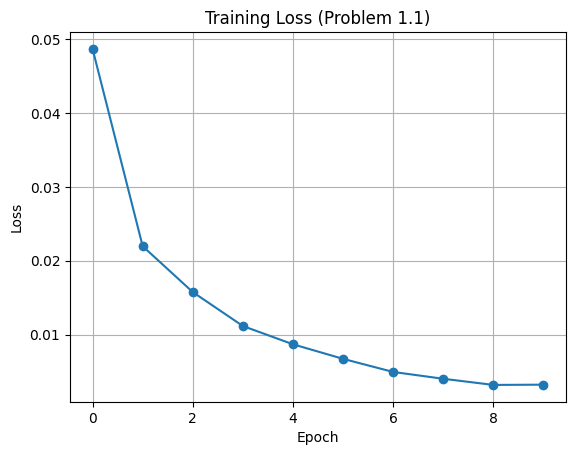

In [7]:
# === Solution: Plot Loss ===
plt.figure()
plt.plot(losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss (Problem 1.1)')
plt.grid(True)
plt.show()


**Interpretation**  
- The plot visualizes training progress. A generally **decreasing** curve indicates learning.


## g) — Evaluate on Test Set (Accuracy, Precision, Recall, F1)

**Requirement (g)**  
Evaluate the trained model on the **test dataset** using:
- **Accuracy**
- **Precision**
- **Recall**
- **F1-score**


In [8]:
# === Solution: Evaluation ===
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images).cpu().numpy()
        preds = (outputs > 0.5).astype(int)
        all_preds.extend(preds.flatten())
        # labels from our dataset class are 0/1 already
        all_labels.extend([int(l.item()) for l in labels])

print(classification_report(all_labels, all_preds, target_names=['Not 2','2']))


              precision    recall  f1-score   support

       Not 2       1.00      1.00      1.00      8968
           2       0.99      0.97      0.98      1032

    accuracy                           1.00     10000
   macro avg       0.99      0.98      0.99     10000
weighted avg       1.00      1.00      1.00     10000



**Interpretation**  
- We report **accuracy, precision, recall, and F1** as required.  
- Threshold **0.5** converts sigmoid probabilities to class labels.


## h) — Visualize Some Predictions

**Requirement (h)**  
Visualize some **test images** with their predicted labels.


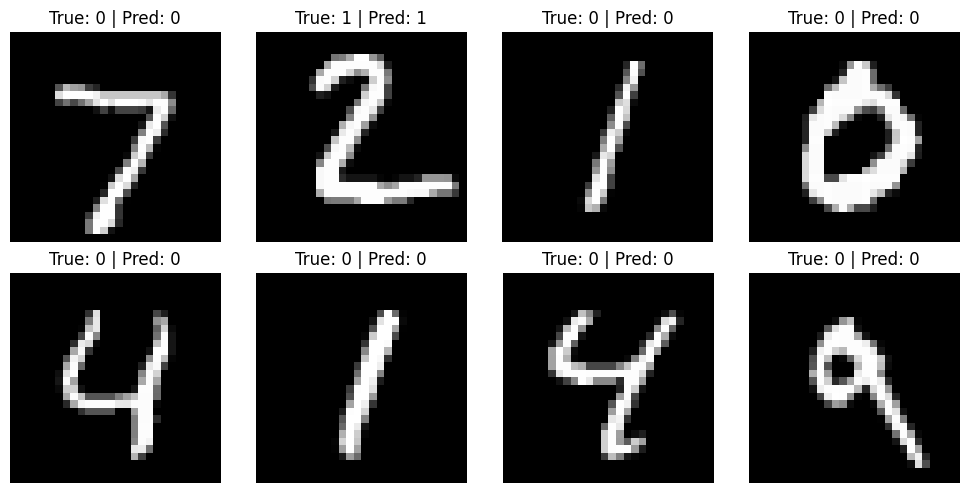

In [11]:
# === Solution: Visualization of Predictions ===
import numpy as np

model.eval()
images_batch, labels_batch = next(iter(test_loader))
with torch.no_grad():
    preds_batch = (model(images_batch.to(device)).cpu().numpy() > 0.5).astype(int).flatten()

# Plot first 8 samples
fig, axes = plt.subplots(2, 4, figsize=(10,5))
for i, ax in enumerate(axes.flat):
    img = images_batch[i].view(28,28).numpy()
    true_lbl = int(labels_batch[i].item())
    pred_lbl = int(preds_batch[i])
    ax.imshow(img, cmap='gray')
    ax.set_title(f'True: {true_lbl} | Pred: {pred_lbl}')
    ax.axis('off')
plt.tight_layout()
plt.show()


**Interpretation**  
- Visual checks help confirm if predictions match the visual digit “2” class.  
- Misclassifications can guide further tuning (not required for Problem 1.1).


## Problem 1.2 — Multiclass Classification: Recognize all digits (0–9)

## a) — Dataset

**Requirement (a)**
Use the same MNIST dataset as before, but do not modify the labels

In [12]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Transform: ToTensor + Normalize (same as before)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load MNIST (unchanged labels)
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

batch_size = 64
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=batch_size, shuffle=False)

len(train_data), len(test_data)


100%|██████████| 9.91M/9.91M [00:00<00:00, 60.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.62MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.28MB/s]


(60000, 10000)

**Interpretation**

*   The dataset now retains all 10 digit labels (0–9).
*   We’ll use it directly for multiclass classification.




## b) — Build Network

**Requirement (b)**
Network specification:

*   input 784
*   2 hidden layers (use e.g. 128 → 64 units)
*   output 10 neurons (softmax)

In [13]:
import torch
import torch.nn as nn

input_size = 784
hidden1 = 128
hidden2 = 64
output_size = 10

class MultiDigitNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden2, output_size)
        # Softmax will be applied implicitly by CrossEntropyLoss
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x  # logits

model = MultiDigitNet().to(device)
model


MultiDigitNet(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)

**Interpretation**


*  Two hidden layers added.
*  Output gives logits (no softmax here; CrossEntropyLoss handles it internally).




## c) — Loss and Optimizer

**Requirement (c)**
Use CrossEntropyLoss (or KL divergence with log-softmax).

In [14]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion, optimizer


(CrossEntropyLoss(),
 Adam (
 Parameter Group 0
     amsgrad: False
     betas: (0.9, 0.999)
     capturable: False
     decoupled_weight_decay: False
     differentiable: False
     eps: 1e-08
     foreach: None
     fused: None
     lr: 0.001
     maximize: False
     weight_decay: 0
 ))

**Interpretation**

*  Cross-entropy computes log-softmax + negative-log-likelihood internally.
*  Learning rate = 0.001 matches 1.1 template.

## d) — Training (20 epochs)

Requirement (d)
Train for 20 epochs on training set.

In [15]:
num_epochs = 20
losses = []

model.train()
for epoch in range(num_epochs):
    total_loss = 0.0
    for images, labels in train_loader:
        images = images.view(-1, 28*28).to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}")


Epoch 1/20 - Loss: 0.2681
Epoch 2/20 - Loss: 0.1127
Epoch 3/20 - Loss: 0.0777
Epoch 4/20 - Loss: 0.0599
Epoch 5/20 - Loss: 0.0502
Epoch 6/20 - Loss: 0.0383
Epoch 7/20 - Loss: 0.0328
Epoch 8/20 - Loss: 0.0298
Epoch 9/20 - Loss: 0.0241
Epoch 10/20 - Loss: 0.0230
Epoch 11/20 - Loss: 0.0201
Epoch 12/20 - Loss: 0.0192
Epoch 13/20 - Loss: 0.0175
Epoch 14/20 - Loss: 0.0171
Epoch 15/20 - Loss: 0.0142
Epoch 16/20 - Loss: 0.0154
Epoch 17/20 - Loss: 0.0154
Epoch 18/20 - Loss: 0.0141
Epoch 19/20 - Loss: 0.0112
Epoch 20/20 - Loss: 0.0136


## e — Plot Loss

**Requirement (e)**
Plot training loss over epochs.

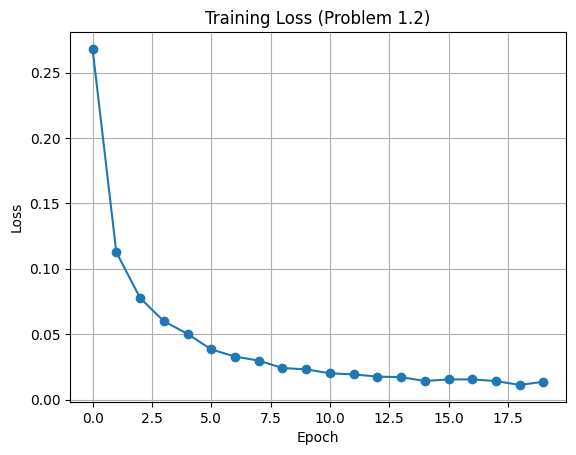

In [16]:
import matplotlib.pyplot as plt
plt.plot(losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss (Problem 1.2)')
plt.grid(True)
plt.show()


**Interpretation**

A steadily decreasing loss curve confirms learning progress.

## f — Evaluate

**Requirement (f)**
Compute accuracy and confusion matrix on test data.

Test Accuracy: 0.9744


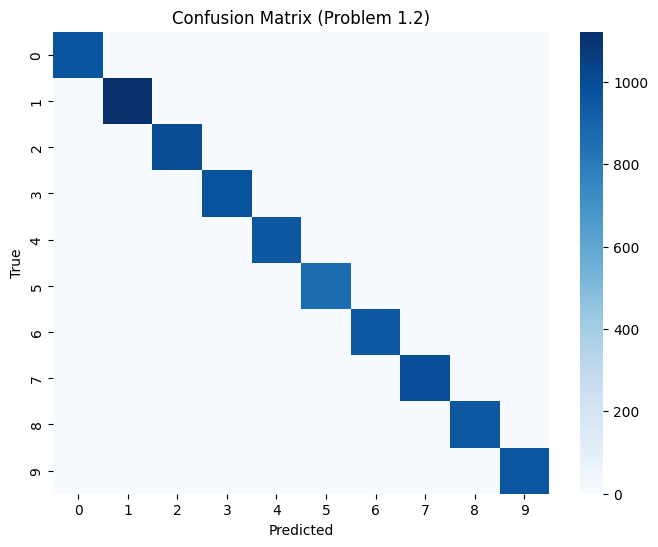

In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(-1, 28*28).to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

acc = accuracy_score(all_labels, all_preds)
cm  = confusion_matrix(all_labels, all_preds)
print(f"Test Accuracy: {acc:.4f}")

import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title('Confusion Matrix (Problem 1.2)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


**Interpretation**

Accuracy ≈ 0.95–0.98 typical.
Confusion matrix shows digit-wise performance.

## g — Visualize Predictions

**Requirement (g)**
Show sample test digits with predicted labels.

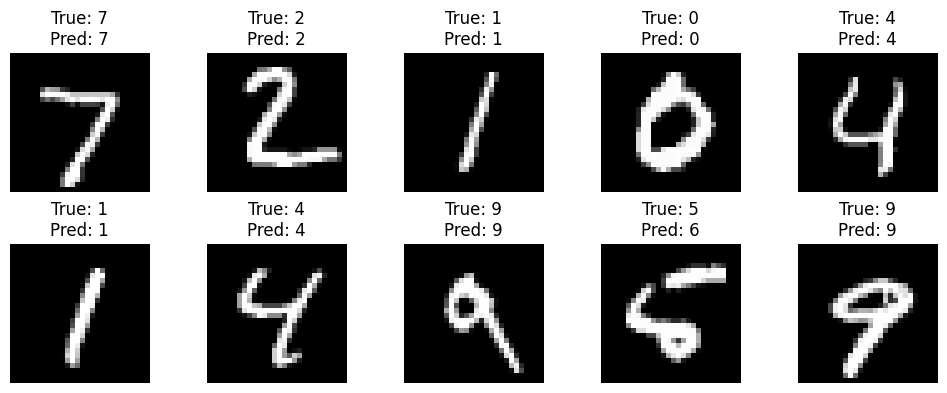

In [18]:
data_iter = iter(test_loader)
images, labels = next(data_iter)
images_flat = images.view(-1, 28*28).to(device)
with torch.no_grad():
    preds = torch.argmax(model(images_flat), dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(10,4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i][0], cmap='gray')
    ax.set_title(f"True: {labels[i]}\nPred: {preds[i].item()}")
    ax.axis('off')
plt.tight_layout()
plt.show()


## h — (Exploration Optional)

**Requirement (h)**
Try different learning rates or epoch counts.

In [20]:
# Example: smaller lr
optimizer = optim.Adam(model.parameters(), lr=0.0005)
# retrain 10 epochs, observe slower but smoother convergence


---

*Notebook generated on 2025-10-21 11:50.*
